In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
# from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import seaborn as sns

In [2]:
df = pd.read_csv("disease_dataset.csv")

In [4]:
df.head()

,id,age,bp,sugar,disease
0,1,70,84,76,0
1,2,45,98,105,0
2,3,73,139,92,1
3,4,32,73,93,0
4,5,62,147,76,1


In [5]:
df.shape

(100, 5)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   id       100 non-null    int64
 1   age      100 non-null    int64
 2   bp       100 non-null    int64
 3   sugar    100 non-null    int64
 4   disease  100 non-null    int64
dtypes: int64(5)
memory usage: 4.0 KB


In [7]:
df.describe()

,id,age,bp,sugar,disease
count,100.000000,100.00000,100.000000,100.000000,100.00000
mean,50.500000,52.60000,116.600000,165.460000,0.57000
std,29.011492,13.83963,26.416248,66.701115,0.49757
min,1.000000,30.00000,71.000000,70.000000,0.00000
25%,25.750000,40.00000,92.500000,103.000000,0.00000
50%,50.500000,51.00000,119.500000,156.000000,1.00000
75%,75.250000,65.00000,139.000000,222.500000,1.00000
max,100.000000,75.00000,159.000000,296.000000,1.00000


In [8]:
df.isnull().sum()

id         0
age        0
bp         0
sugar      0
disease    0
dtype: int64

In [9]:
df.duplicated().sum() # it searches for any duplicate values

np.int64(0)

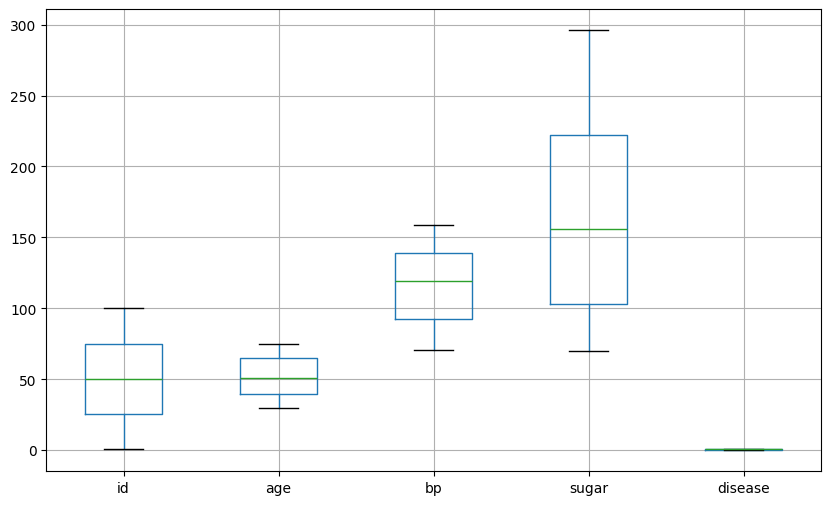

In [10]:
df.boxplot(figsize=(10,6))
plt.show() # we use graph to see if there are any outliers and if yes then we will remove it

In [12]:
X = df[["age","bp","sugar"]]
Y = df["disease"]
X.head()

,age,bp,sugar
0,70,84,76
1,45,98,105
2,73,139,92
3,32,73,93
4,62,147,76


In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.7,
    random_state=42
)
# Variable	    Meaning
# X_train	    Training input data
# y_train	    Training correct answers
# X_test	    Testing input data
# y_test	    Testing correct answers

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model=LogisticRegression()

In [32]:
model.fit(X_train,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [33]:
Y_pred = model.predict(X_test)
accuracy_score(Y_test, Y_pred)

0.8571428571428571

In [38]:
new_patient = [[30,120,180]]
new_patient = scaler.transform(new_patient)
model.predict(new_patient) # the answer will be in zeros and ones as it is classification so yes or no

C:\Users\Priyanshu\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0])

In [42]:
import pickle
pickle.dump(model,open("disease_predictor.pkl","wb"))

In [43]:
pickle.dump(scaler, open("scaler.pkl", "wb"))